In [1]:
import pandas as pd
import os
from glob import glob
import matplotlib.pyplot as plt

from vtools.XRD import read_xrd, calc_vat_frac

In [2]:
fs = [f for f in glob('Data/raw_xrd/*.txt') if 'cal_' not in f and 'vaterite_' not in f]

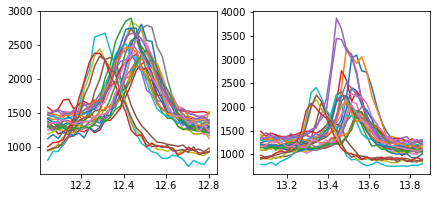

In [3]:
vat_location = 12.42
cal_location = 13.47
window = 0.4

locs = [vat_location, cal_location]

fig, axs = plt.subplots(1, 2, figsize=[7, 3])
for f in fs:
    dat = read_xrd(f)
    for ax, loc in zip(axs, locs):
        ind = (dat.Angle >= loc - window) & (dat.Angle <= loc + window)
        ax.plot(dat.Angle[ind], dat.PSD[ind])

In [4]:
out = pd.DataFrame(columns=['fV'])

for f in fs:
    exp = int(os.path.basename(f).split('_')[0])
    frac = None
    window = 0.4
    while frac is None and window > 0:
        try:
            frac = calc_vat_frac(f, window=window)
        except:
            window -= 0.05
    out.loc[exp, 'fV'] = frac

In [5]:
out.to_pickle('Data/precipitate_mineralogy.pkl')